<h1 style="text-align: center; font-size: 40px; color: gray; font-weight: 700; margin-bottom: 5px;">
    BUSINESS DATA ANALYSIS - CAPSTON PROJECT
</h1>
<h2 style="text-align: center; font-weight: 500; margin-top: 0;">
    SI CEPAT EXPRESS
</h2>

# **Outline**


[**Section 1. Business Understanding**](#1.-Business-Understanding)

[**Section 2. Import Library & Load Data**](#2.-Import-Library-&-Load-Data)

[**Section 3. Exploratory Data Analysis**](#3.-Exploratory-Data-Analysis)

[**Section 4. Data Wrangling & Cleansing**](#4.-Data-Wrangling-&-Cleansing)

[**Section 5. Analisis**](#5.-Analisis)

[**Section 6. Visualisasi Data**](#6.-Visualisasi-Data)

[**Section 7. Hypothesis Testing**](#7.-Hypothesis-Testing)

[**Section 8. Kesimpulan & Rekomendasi**](#8.-Kesimpulan-&-Rekomendasi)

# **1. Business Understanding**

## **1.1 Background**

Pertumbuhan pesat SiCepat Ekspres tidak lepas dari kejelian mereka melihat celah di pasar e-commerce, yakni rasa malas para penjual (seller) untuk mengantar tumpukan paket ke agen logistik. Dengan memperkenalkan layanan penjemputan paket gratis (First-Mile Pickup) berapapun jumlahnya, SiCepat langsung merebut hati jutaan seller UMKM di Tokopedia dan Shopee. Ditambah dengan peluncuran layanan HALU (Harga Mulai Lima Ribu), volume paket harian yang ditangani melonjak hingga jutaan resi per hari.

Namun, strategi hiper-pertumbuhan ini mulai memperlihatkan efek samping di lapangan. Lonjakan request pickup yang masif, terutama saat event mega campaign, membuat kapasitas armada kurir SiGESIT (kurir khusus pickup) kewalahan. Akibatnya, banyak jadwal penjemputan yang molor dari Service Level Agreement (SLA) 1x24 jam. Parahnya lagi, untuk menghindari denda KPI, beberapa kurir melakukan Phantom Pickup—mereka menekan tombol "Pickup Selesai" di aplikasi seolah-olah paket sudah diambil, padahal barangnya masih menumpuk di gudang seller dan baru benar-benar diangkut keesokan harinya. Hal ini memicu amarah seller karena status pesanan pelanggan mereka menggantung.

Di sisi operasional gudang (Hub Sortir), tim Finance dan Data mendeteksi kebocoran omzet (revenue leakage) yang nilainya sangat fantastis. Layanan pengiriman sangat bergantung pada akurasi berat barang. Namun, banyak seller nakal yang sengaja memasukkan "Berat Asumsi" (Stated Weight) 1 kg di aplikasi e-commerce untuk barang bervolume besar seperti helm, bedcover, atau boneka beruang. Ketika paket tersebut masuk ke mesin dimensi Gateway SiCepat, "Berat Volumetrik Aktual"-nya ternyata mencapai 4-5 kg. Jika sistem gagal menagihkan selisih biaya ini ke platform e-commerce, SiCepat membuang ruang kargo truk dan pesawat secara cuma-cuma.

Data logistik harian kini dipenuhi dengan anomali. Pencatatan kategori barang yang dilakukan secara manual oleh seller sangat tidak konsisten, menyulitkan tim Business Intelligence untuk memetakan demografi barang. Belum lagi adanya glitch pada sistem timestamp aplikasi kurir yang membuat pelaporan waktu penjemputan menjadi tidak masuk akal secara kronologis.
Oleh karena itu, analisis mendalam terhadap performa SLA First-Mile Pickup dan rekonsiliasi data Berat Asumsi versus Berat Volumetrik ini sangat kritis untuk segera dilakukan. Jika dibiarkan, SiCepat akan terus membakar uang untuk menutupi kerugian dari paket oversized (kebesaran dimensi) dan secara perlahan ditinggalkan oleh para seller yang lelah dengan janji palsu jadwal penjemputan kurir. Analisis ini adalah kunci untuk menghentikan kebocoran omzet dan menertibkan operasional lini depan.



## **1.2 Problem Statement**

**Masalah Utama**: Tingginya kebocoran pendapatan akibat manipulasi berat volumetrik paket oleh seller serta memburuknya kepercayaan merchant akibat praktik manipulasi data pickup (Phantom Pickup) oleh kurir First-Mile.

**Masalah Turunan**:
1. Berapa estimasi total kerugian (dalam rupiah/kilogram) akibat selisih antara Stated Weight (input seller) dan Actual Volume Weight (hasil scan mesin)?
2. Siapa saja Top 10 Seller yang paling sering merugikan perusahaan melalui praktik manipulasi dimensi paket?
3. Pada jam berapa request pickup paling sering berujung pada SLA Miss (terlambat dijemput lebih dari 24 jam)?
4. Seberapa berantakan pencatatan kolom 'Kategori Barang' (Item Category) di sistem, dan bagaimana cara menstandarisasinya?
5. (Logical Error) Seberapa banyak pesanan yang waktu penjemputannya (Pickup Time) tercatat terjadi sebelum seller melakukan klik permintaan penjemputan (Request Time)?
6. Apakah layanan promo murah seperti HALU menyumbang persentase anomali berat volumetrik lebih besar dibandingkan layanan premium (BEST)?


## **1.3 Goals**

- Revenue Recovery: Menemukan selisih total tonase yang tidak tertagih agar tim Finance bisa melakukan klaim (chargeback) ke pihak E-Commerce.
- Data Cleansing: Menghasilkan tabel data pengiriman yang bersih untuk keperluan Machine Learning prediksi kapasitas truk harian.



## **1.4 Dataset Dictionary**


1. Tabel sicepat_sellers.csv (Dimensi Seller)

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| seller_id | Categorical (Nominal) | ID unik penjual/merchant |
| seller_name | Categorical (Nominal) | Nama toko |
| city | Categorical (Nominal) | Kota lokasi gudang seller |
| join_date | Datetime / Temporal | Tanggal seller bergabung menggunakan SiCepat |

2. Tabel sicepat_services.csv (Dimensi Layanan)

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| service_code | Categorical (Nominal) | Kode unik layanan logistik |
| service_name | Categorical (Nominal) | Nama layanan (HALU, BEST, SIUNTUNG, GOKIL, HALU-COD) |

3. Tabel sicepat_pickups.csv (Fakta Pickup & Berat - 300k baris)

| Nama Kolom | Tipe Data | Deskripsi |
| :--- | :--- | :--- |
| resi_no | Categorical (Nominal) | Nomor resi pengiriman |
| seller_id | Categorical (Nominal) | ID penjual |
| service_code | Categorical (Nominal) | Kode layanan yang dipakai |
| item_category | Categorical (Nominal) | Kategori isi paket |
| request_time | Datetime / Temporal | Tanggal & Jam saat seller klik tombol "Request Pickup" di aplikasi |
| pickup_time | Datetime / Temporal | Tanggal & Jam saat kurir SiGESIT men-scan paket tanda sudah diangkut |
| stated_weight_kg | Numerical (Continuous) | Berat paket yang di-input seller di aplikasi Tokopedia/Shopee |
| actual_volume_weight_kg | Numerical (Continuous) | Berat sesungguhnya berdasarkan dimensi PxLxT saat masuk mesin sortir |
| pickup_status | Categorical (Nominal) | Status penjemputan (Success, Failed, Rescheduled) |



# **2. Import Library & Load Data**

Proses ini menyiapkan semua 'alat bantu' (library) yang dibutuhkan dan juga memuat sekaligus menggabungkan semua dataset

## **2.1 Import Library**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns 
import math  
import warnings 
warnings.filterwarnings('ignore')

# Setting visualisasi
sns.set(style="whitegrid")

## **2.2 Load Data**

In [ ]:
# Load semua dataset : df_sellers, df_services, df_pickups
df_sellers = pd.read_csv('sicepat_sellers.csv')
df_services = pd.read_csv('sicepat_services.csv')
df_pickups = pd.read_csv('sicepat_pickups.csv')

In [ ]:
# Load dataset df_sellers
df_sellers

,seller_id,seller_name,city,join_date
0,SEL-00001,Toko Seller Sukses 0,Cimahi,2021-11-27
1,SEL-00002,Toko Seller Sukses 1,Makassar,2022-02-19
2,SEL-00003,Toko Seller Sukses 2,Cimahi,2021-06-20
3,SEL-00004,Toko Seller Sukses 3,Bandung,2021-09-18
4,SEL-00005,Toko Seller Sukses 4,Medan,2021-06-09
...,...,...,...,...
14995,SEL-14996,Toko Seller Sukses 14995,Sidoarjo,2023-02-03
14996,SEL-14997,Toko Seller Sukses 14996,Jakarta Selatan,2021-11-18
14997,SEL-14998,Toko Seller Sukses 14997,Cimahi,2023-06-07
14998,SEL-14999,Toko Seller Sukses 14998,Sidoarjo,2022-08-26


In [ ]:
# Load dataset df_services
df_services

,service_code,service_name
0,SVC-01,HALU
1,SVC-02,BEST
2,SVC-03,SIUNTUNG
3,SVC-04,GOKIL
4,SVC-05,HALU-COD


In [ ]:
# Load dataset df_pickups 
df_pickups

,resi_no,seller_id,service_code,item_category,request_time,pickup_time,stated_weight_kg,actual_volume_weight_kg,pickup_status
0,000SC000000001,SEL-04246,SVC-05,ksmtk,2023-08-20 15:00:00,2023-08-20 20:11:58.720564,2.51,2.98,Success
1,000SC000000002,SEL-04881,SVC-02,Pakaian,2023-08-14 06:00:00,2023-08-15 01:43:18.472104,-1.50,11.39,Success
2,000SC000000003,SEL-10176,SVC-02,Skincare,2023-09-04 09:00:00,2023-09-05 01:54:57.252587,4.00,4.04,Success
3,000SC000000004,SEL-05400,SVC-02,Kosmetik,2023-11-10 13:00:00,2023-11-11 04:30:11.251160,4.74,5.16,Rescheduled
4,000SC000000005,SEL-08010,SVC-02,NaN,2023-10-03 08:00:00,2023-10-04 07:26:21.201376,4.40,11.69,Success
...,...,...,...,...,...,...,...,...,...
299995,000SC000299996,SEL-04921,SVC-02,Kosmetik,2023-10-25 07:00:00,2023-10-25 21:59:07.346574,3.86,12.19,Success
299996,000SC000299997,SEL-13537,SVC-03,Pakaian,2023-10-12 19:00:00,2023-10-13 18:15:18.236227,2.12,9.56,Success
299997,000SC000299998,SEL-04746,SVC-03,Baju,2023-10-03 16:00:00,2023-10-04 04:02:48.523948,4.30,4.57,Success
299998,000SC000299999,SEL-01880,SVC-05,Kosmetik,2023-08-09 06:00:00,2023-08-09 22:01:10.188472,0.67,5.68,Success


In [ ]:
# Merging dataset df_pickups dan df_sellers = df
df = df_pickups.merge(df_sellers, on='seller_id', how='left')
df

,resi_no,seller_id,service_code,item_category,request_time,pickup_time,stated_weight_kg,actual_volume_weight_kg,pickup_status,seller_name,city,join_date
0,000SC000000001,SEL-04246,SVC-05,ksmtk,2023-08-20 15:00:00,2023-08-20 20:11:58.720564,2.51,2.98,Success,Toko Seller Sukses 4245,Surabaya,2023-06-05
1,000SC000000002,SEL-04881,SVC-02,Pakaian,2023-08-14 06:00:00,2023-08-15 01:43:18.472104,-1.50,11.39,Success,Toko Seller Sukses 4880,Surabaya,2022-12-23
2,000SC000000003,SEL-10176,SVC-02,Skincare,2023-09-04 09:00:00,2023-09-05 01:54:57.252587,4.00,4.04,Success,Toko Seller Sukses 10175,Yogyakarta,2021-12-13
3,000SC000000004,SEL-05400,SVC-02,Kosmetik,2023-11-10 13:00:00,2023-11-11 04:30:11.251160,4.74,5.16,Rescheduled,Toko Seller Sukses 5399,Yogyakarta,2023-04-09
4,000SC000000005,SEL-08010,SVC-02,NaN,2023-10-03 08:00:00,2023-10-04 07:26:21.201376,4.40,11.69,Success,Toko Seller Sukses 8009,Jakarta Pusat,2022-05-26
...,...,...,...,...,...,...,...,...,...,...,...,...
299995,000SC000299996,SEL-04921,SVC-02,Kosmetik,2023-10-25 07:00:00,2023-10-25 21:59:07.346574,3.86,12.19,Success,Toko Seller Sukses 4920,Jakarta Pusat,2023-02-09
299996,000SC000299997,SEL-13537,SVC-03,Pakaian,2023-10-12 19:00:00,2023-10-13 18:15:18.236227,2.12,9.56,Success,Toko Seller Sukses 13536,Jakarta Selatan,2023-07-01
299997,000SC000299998,SEL-04746,SVC-03,Baju,2023-10-03 16:00:00,2023-10-04 04:02:48.523948,4.30,4.57,Success,Toko Seller Sukses 4745,Jakarta Pusat,2023-06-09
299998,000SC000299999,SEL-01880,SVC-05,Kosmetik,2023-08-09 06:00:00,2023-08-09 22:01:10.188472,0.67,5.68,Success,Toko Seller Sukses 1879,Jakarta Pusat,2023-05-20


In [ ]:
# Merging dataset df dan df_services = df_sicepat
df_sicepat = df.merge(df_services, on='service_code', how='left')
df_sicepat

,resi_no,seller_id,service_code,item_category,request_time,pickup_time,stated_weight_kg,actual_volume_weight_kg,pickup_status,seller_name,city,join_date,service_name
0,000SC000000001,SEL-04246,SVC-05,ksmtk,2023-08-20 15:00:00,2023-08-20 20:11:58.720564,2.51,2.98,Success,Toko Seller Sukses 4245,Surabaya,2023-06-05,HALU-COD
1,000SC000000002,SEL-04881,SVC-02,Pakaian,2023-08-14 06:00:00,2023-08-15 01:43:18.472104,-1.50,11.39,Success,Toko Seller Sukses 4880,Surabaya,2022-12-23,BEST
2,000SC000000003,SEL-10176,SVC-02,Skincare,2023-09-04 09:00:00,2023-09-05 01:54:57.252587,4.00,4.04,Success,Toko Seller Sukses 10175,Yogyakarta,2021-12-13,BEST
3,000SC000000004,SEL-05400,SVC-02,Kosmetik,2023-11-10 13:00:00,2023-11-11 04:30:11.251160,4.74,5.16,Rescheduled,Toko Seller Sukses 5399,Yogyakarta,2023-04-09,BEST
4,000SC000000005,SEL-08010,SVC-02,NaN,2023-10-03 08:00:00,2023-10-04 07:26:21.201376,4.40,11.69,Success,Toko Seller Sukses 8009,Jakarta Pusat,2022-05-26,BEST
...,...,...,...,...,...,...,...,...,...,...,...,...,...
299995,000SC000299996,SEL-04921,SVC-02,Kosmetik,2023-10-25 07:00:00,2023-10-25 21:59:07.346574,3.86,12.19,Success,Toko Seller Sukses 4920,Jakarta Pusat,2023-02-09,BEST
299996,000SC000299997,SEL-13537,SVC-03,Pakaian,2023-10-12 19:00:00,2023-10-13 18:15:18.236227,2.12,9.56,Success,Toko Seller Sukses 13536,Jakarta Selatan,2023-07-01,SIUNTUNG
299997,000SC000299998,SEL-04746,SVC-03,Baju,2023-10-03 16:00:00,2023-10-04 04:02:48.523948,4.30,4.57,Success,Toko Seller Sukses 4745,Jakarta Pusat,2023-06-09,SIUNTUNG
299998,000SC000299999,SEL-01880,SVC-05,Kosmetik,2023-08-09 06:00:00,2023-08-09 22:01:10.188472,0.67,5.68,Success,Toko Seller Sukses 1879,Jakarta Pusat,2023-05-20,HALU-COD


## **Insight :**
Library yng digunakan atara lain :
   - import pandas as pd: Mengolah dataset
   - import numpy as np: Menjalankan perhitungan angka skala besar secara cepat 
   - import matplotlib.pyplot as plt: Membuat pengaturan detail (judul & gambar)
   - from scipy import stats adalah perintah untuk mengambil modul
   - import seaborn as sns: Mempercantik tampilan grafik atau visualisasi 
   - import math: Menjalankan rumus matematika khusus (akar, pembulatan)
   - import warnings: Mengatur munculnya pesan peringatan sistem
   - warnings.filterwarnings('ignore'): Mematikan notifikasi peringatan agar tampilan bersih
   - sns.set(style="whitegrid"): Mengaktifkan tema latar putih bergaris agar data mudah dibaca
Dataset yang diupload ada 3 yaitu df_sellers, df_services, df_pickups, untuk selanjutnya dilakukan penggabungkan dan diberikan nama dataset df_sicepat

# **3. Exploratory Data Analysis**

Pendekatan analisis awal untuk memahami karakteristik, pola, hubungan, dan struktur dataset, bertujuan mendeteksi outlier, memeriksa asumsi, dan menangani missing values sebelum melakukan analisis lanjut, guna memastikan hasil analisis akurat

# **3.1 Info & Tipe Data**

In [ ]:
# Memberikan informasi mengenai dataset yang telah digabungkan menjadi 1 data
df_sicepat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   resi_no                  300000 non-null  object 
 1   seller_id                300000 non-null  object 
 2   service_code             300000 non-null  object 
 3   item_category            269991 non-null  object 
 4   request_time             300000 non-null  object 
 5   pickup_time              277552 non-null  object 
 6   stated_weight_kg         300000 non-null  float64
 7   actual_volume_weight_kg  300000 non-null  float64
 8   pickup_status            300000 non-null  object 
 9   seller_name              300000 non-null  object 
 10  city                     300000 non-null  object 
 11  join_date                300000 non-null  object 
 12  service_name             300000 non-null  object 
dtypes: float64(2), object(11)
memory usage: 29.8+ MB


In [ ]:
# Melihat ringkasan statistik deskriptif dari dataframe
df_sicepat.describe()

,stated_weight_kg,actual_volume_weight_kg
count,300000.000000,300000.000000
mean,6.154846,4.154896
std,58.343483,2.836862
min,-1.500000,0.500000
25%,1.610000,2.170000
50%,2.750000,3.550000
75%,3.880000,4.880000
max,999.900000,14.990000


## **3.2 Cek Missing Values & Duplicated**

In [ ]:
# Cek Null
missing     = df_sicepat.isnull().sum()
missing_pct = (missing / len(df_sicepat) * 100).round(2)

result = pd.DataFrame({'Jumlah Missing': missing, 'Persentase (%)': missing_pct})
print('=== MISSING VALUES ===')
display(result[result['Jumlah Missing'] > 0])


=== MISSING VALUES ===


,Jumlah Missing,Persentase (%)
item_category,30009,10.00
pickup_time,22448,7.48


In [ ]:
# Cek Duplicate
df_sicepat.duplicated().sum()

np.int64(0)

## **3.3 Distribusi Nilai Kategorik**

In [ ]:
# Melihat pesebaran jumlah total dan presentase pickup_status
print('=== PICKUP STATUS ===')
sc = df_sicepat['pickup_status'].value_counts()
sp = df_sicepat['pickup_status'].value_counts(normalize=True).mul(100).round(2)
display(pd.DataFrame({'Jumlah':sc,'Persen (%)':sp}))

# Melihat pesebaran jumlah total service_name
print('\n=== LAYANAN ===')
display(df_sicepat['service_name'].value_counts())

# Melihat pesebaran jumlah total item_category
print('\n=== ITEM CATEGORY  ===')
display(df_sicepat['item_category'].value_counts())


=== PICKUP STATUS ===


,Jumlah,Persen (%)
pickup_status,,
Success,254992,85.00
Failed,30090,10.03
Rescheduled,14918,4.97



=== LAYANAN ===


service_name
HALU        150107
HALU-COD     60003
BEST         45079
SIUNTUNG     29874
GOKIL        14937
Name: count, dtype: int64


=== ITEM CATEGORY  ===


item_category
Baju          45250
Kosmetik      44985
baju          30040
Fashion       29942
Pakaian       29874
Skincare      29802
Elektronik    15087
ksmtk         15003
hp            14975
Sepatu        12025
spt            3008
Name: count, dtype: int64

## **Insight :**
- Total terdapat 300.000 ribu baris dan 13 kolom
- Kolom request_time, pickup_time, dan join_date masih bertipe string/object
- Terdapat data outlier dimana:
    - stated_weight_kg min : -1,5 kg (Ada Nilai Negatif)
    - stated_weight_kg max : 999,9 kg (Ada Nilai Ekstrem)
- stated_weight_kg std : 58.34 (Menandakan nilai penyimpangan terlalu besar dari pesebaran data)
- actual_volume_weight_kg : 0.5 kg - 15 kg (Rentang wajar)
- Terdapat nilai null pada :
    - Kolom item_category  : 30,009 baris (10.0%), kemungkinan seller tidak mengisi kategori
    - Kolom pickup_time     : 22,448 baris (7.5%) dengan status pada kolom paket_status Failed/Rescheduled (belum dijemput)
- Tidak ada data duplikat
- penamaan kategori pada kolom item_category tidak konsisten dan perlu di standarisasi

# **4. Data Wrangling & Cleansing**

Tahap merapikan data mentah agar siap dianalisis, ada tiga langkah yang akan dilakukan yaitu : mengkonversi tipe data waktu, menemukan data outlier, menstandarisasi kategori barang agar konsisten

## **4.1 Konversi Tipe Data Waktu**

In [ ]:
# Konversi request_time, pickup_time, join_date string menjadi datetime
df_sicepat['request_time'] = pd.to_datetime(df_sicepat['request_time'])
df_sicepat['pickup_time']  = pd.to_datetime(df_sicepat['pickup_time'])
df_sicepat['join_date']    = pd.to_datetime(df_sicepat['join_date'])
df_sicepat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   resi_no                  300000 non-null  object        
 1   seller_id                300000 non-null  object        
 2   service_code             300000 non-null  object        
 3   item_category            269991 non-null  object        
 4   request_time             300000 non-null  datetime64[ns]
 5   pickup_time              277552 non-null  datetime64[ns]
 6   stated_weight_kg         300000 non-null  float64       
 7   actual_volume_weight_kg  300000 non-null  float64       
 8   pickup_status            300000 non-null  object        
 9   seller_name              300000 non-null  object        
 10  city                     300000 non-null  object        
 11  join_date                300000 non-null  datetime64[ns]
 12  service_name    

## **4.2 Flagging Outlier - Berat Paket**

In [ ]:
# Batas logis: 0.1 kg (dokumen) s/d 100 kg (batas kargo reguler)
print('=== OUTLIER stated_weight_kg ===')
print(f"Nilai negatif (< 0)  : {(df_sicepat['stated_weight_kg'] < 0).sum():,}")
print(f"Nilai < 0.1 kg        : {(df_sicepat['stated_weight_kg'] < 0.1).sum():,}")
print(f"Nilai > 100 kg        : {(df_sicepat['stated_weight_kg'] > 100).sum():,}")

# Tambah kolom boolean flag — tidak menghapus data
df_sicepat['is_weight_valid'] = (
    (df_sicepat['stated_weight_kg'] >= 0.1) &
    (df_sicepat['stated_weight_kg'] <= 100)
)

n_valid   = df_sicepat['is_weight_valid'].sum()
n_invalid = (~df_sicepat['is_weight_valid']).sum()
print(f'\nBerat valid   : {n_valid:,} baris ({n_valid/len(df_sicepat)*100:.1f}%)')
print(f'Berat invalid : {n_invalid:,} baris ({n_invalid/len(df_sicepat)*100:.1f}%)')

=== OUTLIER stated_weight_kg ===
Nilai negatif (< 0)  : 969
Nilai < 0.1 kg        : 1,970
Nilai > 100 kg        : 1,030

Berat valid   : 297,000 baris (99.0%)
Berat invalid : 3,000 baris (1.0%)


## **4.3 Standarisasi Item Category**

In [ ]:
# Mapping: nilai_kotor → nilai_standar
category_item = {
    'baju':'Fashion & Pakaian', 'Baju':'Fashion & Pakaian',
    'Pakaian':'Fashion & Pakaian', 'Fashion':'Fashion & Pakaian',
    'Sepatu':'Fashion & Pakaian', 'spt':'Fashion & Pakaian',
    'Kosmetik':'Kosmetik & Skincare', 'ksmtk':'Kosmetik & Skincare',
    'Skincare':'Kosmetik & Skincare',
    'Elektronik':'Elektronik & Gadget', 'hp':'Elektronik & Gadget',
}

df_sicepat['item_category_clean'] = df_sicepat['item_category'].map(category_item).fillna('Lainnya / Tidak Diketahui')

display(df_sicepat['item_category_clean'].value_counts().reset_index())

,item_category_clean,count
0,Fashion & Pakaian,150139
1,Kosmetik & Skincare,89790
2,Elektronik & Gadget,30062
3,Lainnya / Tidak Diketahui,30009


### **Insight**
- Kolom request_time dan pickup_time tersimpan sebagai string (teks), akibatnya Python tidak bisa menghitung selisih waktunya (misalnya: 'berapa jam dari request sampai pickup?') sehingga perlu di ubah ke format datetime
- Ditemukan nilai berat yang tidak masuk akal pada kolom 'stated_weight_kg'. Terdapat angka yang negatif (-1.5 kg) dan ada yang ekstrem (999.9 kg). Solusinya diberikan tanda (flag) paket yang tidak valid dan tidak dihapus, agar data tetap bisa diaudit. solusinya menambahkan kolom is_weight_valid yang berisi :
    - True  = berat antara 0.1–100 kg = data valid 
    - False = berat < 0.1 atau > 100 kg = outlier, ditandai 
- Terdapat kategori barang yang penulisan dan pengkategoriannya tidak konsisten sehingga perlu dilakukan standarisasi. Dari 11 kategori, saya membuat standarisasi dengan 4 kategori barang, yaitu Fashion & Pakaian, Kosmetik & Skincare, Elektronik & Gadget, Lainnya / Tidak Diketahui	

# **5. Analisis**

## **5.1 Revenue Leakage** 
terjadi saat actual_volume_weight_kg > stated_weight_kg — selisih berat ini tidak tertagih ke marketplace.
Revenue Leakage per paket = actual_volume_weight_kg − stated_weight_kg


In [ ]:
# ─ Filter data berat valid
df_valid = df_sicepat[df_sicepat['is_weight_valid']].copy()

# Hitung selisih berat (positif = under-state = leakage)
df_valid['weight_diff_kg'] = df_valid['actual_volume_weight_kg'] - df_valid['stated_weight_kg']

# Filter hanya paket under-stated
df_leakage = df_valid[df_valid['weight_diff_kg'] > 0]

RATE_PER_KG = 7_000  # Asumsi tarif Rp 7.000/kg (underscore Python = pemisah ribuan)

total_kg    = df_leakage['weight_diff_kg'].sum()  
avg_diff    = df_leakage['weight_diff_kg'].mean()  
n_paket     = len(df_leakage)
est_loss_rp = total_kg * RATE_PER_KG

print('=' * 58)
print('             RINGKASAN REVENUE LEAKAGE')
print('=' * 58)
print(f'  Paket under-stated          : {n_paket:>10,} resi')
print(f'  % dari data valid           : {n_paket/len(df_valid)*100:>9.1f}%')
print(f'  Total berat tidak tertagih  : {total_kg:>10,.2f} kg')
print(f'  Rata-rata selisih/paket     : {avg_diff:>10.2f} kg')
print(f'  Estimasi Kerugian @Rp7k/kg  : Rp {est_loss_rp:>15,.0f}')
print('=' * 58)


             RINGKASAN REVENUE LEAKAGE
  Paket under-stated          :    294,549 resi
  % dari data valid           :      99.2%
  Total berat tidak tertagih  : 416,161.27 kg
  Rata-rata selisih/paket     :       1.41 kg
  Estimasi Kerugian @Rp7k/kg  : Rp   2,913,128,890


### **5.1.1 Standarisasi Berat & Rekalibrasi Revenue Leakage**

**Latar Belakang:**  
- Hasil analisis Section 4 menunjukkan **294.549 paket (99.2%)** terdeteksi sebagai
- revenue leakage dengan total **416.161,27 kg** tidak tertagih.  
- Setelah ditelusuri, penyebab utamanya adalah **inkonsistensi penulisan desimal**
- antara stated_weight_kg dan actual_volume_weight_kg.  
- Contoh: stated = 2.51 kg vs actual = 2.98 kg → selisih 0.47 kg, padahal
- keduanya secara fisik sama-sama **3 kg** jika dibulatkan.

**Aturan Standarisasi Berat**

| Bagian Desimal | Aturan | Contoh |
|---|---|---|
| ,00 – ,30 | Bulatkan ke **bawah** (floor) | 2.30 → 2, 3.15 → 3 |
| ,31 – ,99 | Bulatkan ke **atas** (ceil)  | 2.31 → 3, 4.75 → 5 |

**Tujuan**
Menghitung ulang revenue leakage yang **murni terjadi karena manipulasi berat**,
bukan karena perbedaan penulisan desimal yang seharusnya menghasilkan angka bulat sama.

## **5.1.2 Terapkan Standarisasi ke Dataset**

In [ ]:
# FUNGSI PEMBULATAN STANDAR BERAT SiCepat
# Aturan:
#   Desimal ,00 – ,30  →  bulatkan ke BAWAH  (math.floor)
#   Desimal ,31 – ,99  →  bulatkan ke ATAS   (math.ceil)

def bulatkan_standar(x):
    """
    Membulatkan berat paket sesuai standar SiCepat.
    - Desimal 0.00 – 0.30 : floor (bulatkan ke bawah)
    - Desimal 0.31 – 0.99 : ceil  (bulatkan ke atas)

    Parameter:
        x (float): nilai berat dalam kg
    Returns:
        int: nilai berat setelah dibulatkan
    """

    desimal = round(x % 1, 10)   

    if desimal <= 0.30:
        return math.floor(x)      # Bulatkan ke bawah: 2.30 → 2
    else:
        return math.ceil(x)       # Bulatkan ke atas : 2.31 → 3


# ── Uji fungsi dengan nilai contoh ───────────────────────────────────────
contoh = [
    (1.00, 'desimal 0.00 → floor'), (1.29, 'desimal 0.29 → floor'),
    (1.30, 'desimal 0.30 → floor'), (1.31, 'desimal 0.31 → ceil'),
    (1.50, 'desimal 0.50 → ceil'),  (1.99, 'desimal 0.99 → ceil'),
    (2.51, 'kasus nyata: stated'), (2.98, 'kasus nyata: actual'),
]

print(f'  {"Nilai Asli":>10}  {"Hasil":>8}  Keterangan')
print('-' * 52)
for nilai, ket in contoh:
    print(f'  {nilai:>10.2f}  →  {bulatkan_standar(nilai):>5}    {ket}')

print()
print(' Contoh kasus:')
print(f'   stated = 2.51 kg  → {bulatkan_standar(2.51)} kg')
print(f'   actual = 2.98 kg  → {bulatkan_standar(2.98)} kg')
print(f'   Selisih setelah standarisasi: {bulatkan_standar(2.98) - bulatkan_standar(2.51)} kg')
print(f'   → Keduanya menjadi 3 kg, selisih = 0 (BUKAN leakage!)')


  Nilai Asli     Hasil  Keterangan
----------------------------------------------------
        1.00  →      1    desimal 0.00 → floor
        1.29  →      1    desimal 0.29 → floor
        1.30  →      1    desimal 0.30 → floor
        1.31  →      2    desimal 0.31 → ceil
        1.50  →      2    desimal 0.50 → ceil
        1.99  →      2    desimal 0.99 → ceil
        2.51  →      3    kasus nyata: stated
        2.98  →      3    kasus nyata: actual

 Contoh kasus:
   stated = 2.51 kg  → 3 kg
   actual = 2.98 kg  → 3 kg
   Selisih setelah standarisasi: 0 kg
   → Keduanya menjadi 3 kg, selisih = 0 (BUKAN leakage!)


### **5.1.3 Terapkan Standarisasi ke Dataset**

In [ ]:
# TERAPKAN FUNGSI PEMBULATAN KE KEDUA KOLOM BERAT
df_std = df_valid.copy()

# Terapkan fungsi ke kolom stated_weight_kg 
df_std['stated_rounded'] = df_std['stated_weight_kg'].apply(bulatkan_standar)
# Hasilnya: kolom baru berisi nilai bulat sesuai aturan standarisasi

# Terapkan fungsi ke kolom actual_volume_weight_kg 
df_std['actual_rounded'] = df_std['actual_volume_weight_kg'].apply(bulatkan_standar)

# Hitung selisih berat SETELAH standarisasi 
df_std['weight_diff_std'] = df_std['actual_rounded'] - df_std['stated_rounded']

# Menampilkan 15 baris perbandingan 
kolom_tampil = [
    'resi_no',
    'stated_weight_kg', 'stated_rounded',
    'actual_volume_weight_kg', 'actual_rounded',
    'weight_diff_std'
]
print('=== 15 Baris Contoh — Sebelum vs Sesudah Standarisasi ===')
print(f'{"Resi":>16}  {"Stated":>7}  {"→Std":>5}  {"Actual":>7}  {"→Std":>5}  {"Selisih":>7}')
print('-' * 62)
for _, r in df_std[kolom_tampil].head(15).iterrows():
    flag = '  ← tidak leakage' if r['weight_diff_std'] == 0 else ''
    print(f"{r['resi_no']:>16}  "
          f"{r['stated_weight_kg']:>7.2f}  "
          f"{int(r['stated_rounded']):>5}  "
          f"{r['actual_volume_weight_kg']:>7.2f}  "
          f"{int(r['actual_rounded']):>5}  "
          f"{int(r['weight_diff_std']):>7}{flag}")


=== 15 Baris Contoh — Sebelum vs Sesudah Standarisasi ===
            Resi   Stated   →Std   Actual   →Std  Selisih
--------------------------------------------------------------
  000SC000000001     2.51      3     2.98      3        0  ← tidak leakage
  000SC000000003     4.00      4     4.04      4        0  ← tidak leakage
  000SC000000004     4.74      5     5.16      5        0  ← tidak leakage
  000SC000000005     4.40      5    11.69     12        7
  000SC000000006     0.63      1     9.86     10        9
  000SC000000007     3.77      4     4.00      4        0  ← tidak leakage
  000SC000000008     2.99      3     3.21      3        0  ← tidak leakage
  000SC000000009     1.61      2     2.08      2        0  ← tidak leakage
  000SC000000010     2.63      3     6.05      6        3
  000SC000000011     0.57      1     0.91      1        0  ← tidak leakage
  000SC000000012     4.77      5     4.99      5        0  ← tidak leakage
  000SC000000013     4.44      5     4.88      

### **5.1.4 Rekalibrasi Revenue Leakage**

In [ ]:
# REKALIBRASI: Hitung ulang revenue leakage setelah standarisasi

# Filter hanya paket yang benar-benar leakage setelah standarisasi
df_leakage_std = df_std[df_std['weight_diff_std'] > 0].copy()

# Hitung metrik utama
RATE_PER_KG = 7_000

# SEBELUM standarisasi
n_sblm        = len(df_leakage)                          # Jumlah paket leakage lama
total_kg_sblm = df_leakage['weight_diff_kg'].sum()       # Total kg tidak tertagih lama

# SESUDAH standarisasi
n_std_leakage = len(df_leakage_std)                      # Jumlah paket leakage baru
total_kg_std  = df_leakage_std['weight_diff_std'].sum()  # Total kg tidak tertagih baru
avg_diff_std  = df_leakage_std['weight_diff_std'].mean() # Rata-rata selisih per paket
est_loss_std  = total_kg_std * RATE_PER_KG               # Estimasi kerugian baru

# Paket yang 'diselamatkan' (sebelumnya terhitung leakage, ternyata bukan)
n_diselamatkan      = n_sblm - n_std_leakage
kg_diselamatkan     = total_kg_sblm - total_kg_std
saving_rp           = kg_diselamatkan * RATE_PER_KG

print('=' * 65)
print('     REKALIBRASI REVENUE LEAKAGE — SETELAH STANDARISASI BERAT')
print('=' * 65)
print(f'  {"":45} {"SEBELUM":>10}  {"SESUDAH":>10}')
print(f'  {"-"*64}')
print(f'  {"Paket under-stated":45} {n_sblm:>10,}  {n_std_leakage:>10,}')
print(f'  {"% dari data valid":45} '
      f'{n_sblm/len(df_valid)*100:>9.1f}%  '
      f'{n_std_leakage/len(df_valid)*100:>9.1f}%')
print(f'  {"Total berat tidak tertagih (kg)":45} '
      f'{total_kg_sblm:>10,.2f}  '
      f'{total_kg_std:>10,.2f}')
print(f'  {"Rata-rata selisih/paket (kg)":45} '
      f'{df_leakage["weight_diff_kg"].mean():>10.2f}  '
      f'{avg_diff_std:>10.2f}')
print(f'  {"Estimasi Kerugian @Rp7.000/kg":45} '
      f'Rp {total_kg_sblm*RATE_PER_KG:>13,.0f}  '
      f'Rp {est_loss_std:>13,.0f}')
print(f'  {"-"*64}')
print(f'  {"Paket yang bukan leakage (diselamatkan)":45} {n_diselamatkan:>10,}')
print(f'  {"Berat yang bukan leakage (kg)":45} {kg_diselamatkan:>10,.2f}')
print(f'  {"Koreksi estimasi kerugian":45} Rp {saving_rp:>13,.0f}')
print('=' * 65)
print(f'\n Setelah standarisasi desimal, paket yang BENAR-BENAR leakage:')
print(f'   {n_std_leakage:,} paket ({n_std_leakage/len(df_valid)*100:.1f}% dari data valid)')
print(f'   Total berat : {total_kg_std:,.2f} kg')
print(f'   Est. kerugian: Rp {est_loss_std:,.0f}')

     REKALIBRASI REVENUE LEAKAGE — SETELAH STANDARISASI BERAT
                                                   SEBELUM     SESUDAH
  ----------------------------------------------------------------
  Paket under-stated                               294,549     114,283
  % dari data valid                                  99.2%       38.5%
  Total berat tidak tertagih (kg)               416,161.27  411,115.00
  Rata-rata selisih/paket (kg)                        1.41        3.60
  Estimasi Kerugian @Rp7.000/kg                 Rp 2,913,128,890  Rp 2,877,805,000
  ----------------------------------------------------------------
  Paket yang bukan leakage (diselamatkan)          180,266
  Berat yang bukan leakage (kg)                   5,046.27
  Koreksi estimasi kerugian                     Rp    35,323,890

 Setelah standarisasi desimal, paket yang BENAR-BENAR leakage:
   114,283 paket (38.5% dari data valid)
   Total berat : 411,115.00 kg
   Est. kerugian: Rp 2,877,805,000


### **5.1.5 Top 10 Seller**

In [ ]:
# TOP 10 SELLER — berdasarkan data leakage yang sudah distandarkan
top10_std = (
    df_leakage_std
    .groupby(['seller_id', 'seller_name'])['weight_diff_std']
    .agg(
        total_kg_leakage = 'sum',    # Total kg tidak tertagih per seller
        jumlah_paket     = 'count',  # Berapa kali seller melakukannya
    )
    .sort_values('total_kg_leakage', ascending=False)
    .head(10)
    .reset_index() 
)

# Tambah kolom turunan
top10_std['rata_kg_per_paket'] = (
    top10_std['total_kg_leakage'] / top10_std['jumlah_paket']
).round(2)

top10_std['est_kerugian_rp'] = top10_std['total_kg_leakage'].apply(
    lambda x: f'Rp {x * RATE_PER_KG:,.0f}'
)

print('=== TOP 10 SELLER — REVENUE LEAKAGE (setelah standarisasi berat) ===')
display(top10_std[[
    'seller_id', 'seller_name',
    'jumlah_paket', 'total_kg_leakage',
    'rata_kg_per_paket', 'est_kerugian_rp'
]])

=== TOP 10 SELLER — REVENUE LEAKAGE (setelah standarisasi berat) ===


,seller_id,seller_name,jumlah_paket,total_kg_leakage,rata_kg_per_paket,est_kerugian_rp
0,SEL-00974,Toko Seller Sukses 973,17,90,5.29,"Rp 630,000"
1,SEL-11649,Toko Seller Sukses 11648,16,88,5.50,"Rp 616,000"
2,SEL-06585,Toko Seller Sukses 6584,17,88,5.18,"Rp 616,000"
3,SEL-06275,Toko Seller Sukses 6274,13,87,6.69,"Rp 609,000"
4,SEL-10204,Toko Seller Sukses 10203,16,86,5.38,"Rp 602,000"
5,SEL-11794,Toko Seller Sukses 11793,19,83,4.37,"Rp 581,000"
6,SEL-14720,Toko Seller Sukses 14719,14,81,5.79,"Rp 567,000"
7,SEL-13603,Toko Seller Sukses 13602,17,80,4.71,"Rp 560,000"
8,SEL-05279,Toko Seller Sukses 5278,15,80,5.33,"Rp 560,000"
9,SEL-14898,Toko Seller Sukses 14897,13,77,5.92,"Rp 539,000"


### **5.1.6 VISUALISASI PERBANDINGAN — Sebelum vs Sesudah Standarisasi Berat**

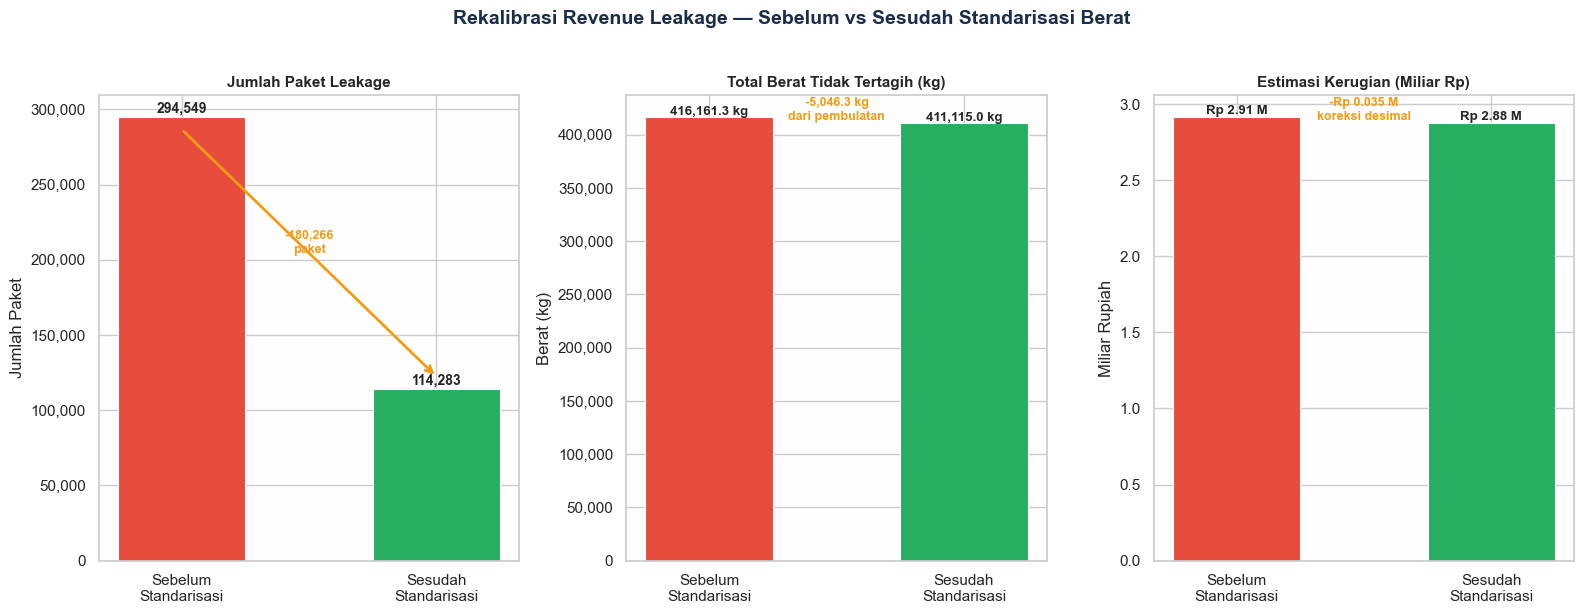

 Setelah pembulatan standar:
   Paket leakage turun: 294,549 → 114,283 (180,266 paket tereliminasi)
   Berat koreksi      : 5,046.27 kg (perbedaan penulisan desimal)
   Kerugian RIIL      : Rp 2,877,805,000


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Rekalibrasi Revenue Leakage — Sebelum vs Sesudah Standarisasi Berat',
             fontsize=14, fontweight='bold', color='#1A2E4A', y=1.02)

WARNA_SBLM = '#E74C3C'   # Merah  = sebelum standarisasi
WARNA_STLH = '#27AE60'   # Hijau  = sesudah standarisasi
WARNA_SEL  = '#F39C12'   # Kuning = selisih / diselamatkan

# Chart 1: Jumlah Paket Leakage 
ax = axes[0]
# ax.bar() → bar chart vertikal
bars0 = ax.bar(['Sebelum\nStandarisasi', 'Sesudah\nStandarisasi'],
               [n_sblm, n_std_leakage],
               color=[WARNA_SBLM, WARNA_STLH],
               edgecolor='white', linewidth=0.8, width=0.5)

# Tambah label nilai di atas setiap bar
for bar in bars0:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 3000,
            f'{int(h):,}', ha='center', fontsize=10, fontweight='bold')

# Anotasi panah pengurangan
ax.annotate('',
            xy=(1, n_std_leakage + 8000),
            xytext=(0, n_sblm - 8000),
            arrowprops=dict(arrowstyle='->', color=WARNA_SEL, lw=2))
ax.text(0.5, (n_sblm + n_std_leakage)/2,
        f'-{n_diselamatkan:,}\npaket',
        ha='center', color=WARNA_SEL, fontsize=9, fontweight='bold')

ax.set_title('Jumlah Paket Leakage', fontweight='bold', fontsize=11)
ax.set_ylabel('Jumlah Paket')


import matplotlib.ticker as mticker
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.set_facecolor('#FEFEFE')

# Chart 2: Total Berat Tidak Tertagih
ax = axes[1]
bars1 = ax.bar(['Sebelum\nStandarisasi', 'Sesudah\nStandarisasi'],
               [total_kg_sblm, total_kg_std],
               color=[WARNA_SBLM, WARNA_STLH],
               edgecolor='white', linewidth=0.8, width=0.5)

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 2000,
            f'{h:,.1f} kg', ha='center', fontsize=9.5, fontweight='bold')

ax.text(0.5, (total_kg_sblm + total_kg_std)/2,
        f'-{kg_diselamatkan:,.1f} kg\ndari pembulatan',
        ha='center', color=WARNA_SEL, fontsize=9, fontweight='bold')

ax.set_title('Total Berat Tidak Tertagih (kg)', fontweight='bold', fontsize=11)
ax.set_ylabel('Berat (kg)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.set_facecolor('#FEFEFE')

# Chart 3: Estimasi Kerugian (Rp)
ax = axes[2]
est_sblm_m = (total_kg_sblm * RATE_PER_KG) / 1e9 
est_stlh_m = est_loss_std / 1e9

bars2 = ax.bar(['Sebelum\nStandarisasi', 'Sesudah\nStandarisasi'],
               [est_sblm_m, est_stlh_m],
               color=[WARNA_SBLM, WARNA_STLH],
               edgecolor='white', linewidth=0.8, width=0.5)

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
            f'Rp {h:.2f} M', ha='center', fontsize=9.5, fontweight='bold')

ax.text(0.5, (est_sblm_m + est_stlh_m)/2,
        f'-Rp {(est_sblm_m-est_stlh_m):.3f} M\nkoreksi desimal',
        ha='center', color=WARNA_SEL, fontsize=9, fontweight='bold')

ax.set_title('Estimasi Kerugian (Miliar Rp)', fontweight='bold', fontsize=11)
ax.set_ylabel('Miliar Rupiah')
ax.set_facecolor('#FEFEFE')

plt.tight_layout()
plt.show()
print(f' Setelah pembulatan standar:')
print(f'   Paket leakage turun: {n_sblm:,} → {n_std_leakage:,} ({n_diselamatkan:,} paket tereliminasi)')
print(f'   Berat koreksi      : {kg_diselamatkan:,.2f} kg (perbedaan penulisan desimal)')
print(f'   Kerugian RIIL      : Rp {est_loss_std:,.0f}')

### **5.1.7 Menyimpan Dataset Standar untuk Analisis Selanjutnya**

In [ ]:
# SIMPAN KOLOM HASIL STANDARISASI KE df_valid agar bisa digunakan di analisis berikutny

# Tambahkan kolom hasil standarisasi ke df_valid yang sudah ada
df_valid.loc[:, 'stated_rounded']  = df_valid['stated_weight_kg'].apply(bulatkan_standar)
df_valid.loc[:, 'actual_rounded']  = df_valid['actual_volume_weight_kg'].apply(bulatkan_standar)
df_valid.loc[:, 'weight_diff_std'] = df_valid['actual_rounded'] - df_valid['stated_rounded']

# Update variabel df_leakage, gunakan data yang sudah distandarkan
df_leakage = df_valid[df_valid['weight_diff_std'] > 0].copy()

print(' Kolom standarisasi berhasil ditambahkan ke df_valid:')
print(f'   stated_rounded   → berat stated setelah dibulatkan (int)')
print(f'   actual_rounded   → berat actual setelah dibulatkan (int)')
print(f'   weight_diff_std  → selisih aktual setelah standarisasi')
print()
print(f' df_leakage diperbarui: {len(df_leakage):,} paket (leakage RIIL)')
print()
print('Kolom df_valid saat ini:')
print([c for c in df_valid.columns])


 Kolom standarisasi berhasil ditambahkan ke df_valid:
   stated_rounded   → berat stated setelah dibulatkan (int)
   actual_rounded   → berat actual setelah dibulatkan (int)
   weight_diff_std  → selisih aktual setelah standarisasi

 df_leakage diperbarui: 114,283 paket (leakage RIIL)

Kolom df_valid saat ini:
['resi_no', 'seller_id', 'service_code', 'item_category', 'request_time', 'pickup_time', 'stated_weight_kg', 'actual_volume_weight_kg', 'pickup_status', 'seller_name', 'city', 'join_date', 'service_name', 'is_weight_valid', 'item_category_clean', 'weight_diff_kg', 'stated_rounded', 'actual_rounded', 'weight_diff_std']


In [ ]:
df_leakage.head()

,resi_no,seller_id,service_code,item_category,request_time,pickup_time,stated_weight_kg,actual_volume_weight_kg,pickup_status,seller_name,city,join_date,service_name,is_weight_valid,item_category_clean,weight_diff_kg,stated_rounded,actual_rounded,weight_diff_std
4,000SC000000005,SEL-08010,SVC-02,NaN,2023-10-03 08:00:00,2023-10-04 07:26:21.201376,4.40,11.69,Success,Toko Seller Sukses 8009,Jakarta Pusat,2022-05-26,BEST,True,Lainnya / Tidak Diketahui,7.29,5,12,7
5,000SC000000006,SEL-07427,SVC-01,Sepatu,2023-08-16 15:00:00,2023-08-17 10:31:01.411954,0.63,9.86,Success,Toko Seller Sukses 7426,Makassar,2022-08-19,HALU,True,Fashion & Pakaian,9.23,1,10,9
9,000SC000000010,SEL-00879,SVC-01,NaN,2023-10-02 14:00:00,2023-10-03 09:11:44.662081,2.63,6.05,Success,Toko Seller Sukses 878,Medan,2022-07-08,HALU,True,Lainnya / Tidak Diketahui,3.42,3,6,3
13,000SC000000014,SEL-02420,SVC-01,Baju,2023-12-25 12:00:00,NaT,3.24,10.03,Failed,Toko Seller Sukses 2419,Yogyakarta,2023-02-26,HALU,True,Fashion & Pakaian,6.79,3,10,7
14,000SC000000015,SEL-02688,SVC-01,Kosmetik,2023-10-19 16:00:00,2023-10-20 10:48:33.690709,2.38,12.27,Success,Toko Seller Sukses 2687,Jakarta Selatan,2022-09-04,HALU,True,Kosmetik & Skincare,9.89,3,12,9


## **5.2 Analisis SLA & Phantom Pickup**

| Istilah | Definisi |
|---|---|
| **SLA Hit** | Paket dijemput dalam ≤24 jam setelah request |
| **SLA Miss** | Paket dijemput >24 jam setelah request (pelanggaran) |
| **Phantom Pickup** | pickup_time < request_time — mustahil secara logika, tanda manipulasi |


### **5.2.1 Deteksi Phantom Pickup**

In [ ]:
# Kondisi phantom: status Success TAPI pickup_time < request_time
phantom = df_valid[
    (df_valid['pickup_status'] == 'Success') &     
    (df_valid['pickup_time'].notna()) &        
    (df_valid['pickup_time'] < df_valid['request_time']) 
]

n_phantom = len(phantom)
n_success = (df_valid['pickup_status'] == 'Success').sum()

print('=' * 55)
print('              PHANTOM PICKUP SUMMARY')
print('=' * 55)
print(f'  Total transaksi Success     : {n_success:>10,}')
print(f'  Terdeteksi Phantom Pickup   : {n_phantom:>10,}')
print(f'  % dari total transaksi      : {n_phantom/len(df_valid)*100:>9.2f}%')
print(f'  % dari transaksi Success    : {n_phantom/n_success*100:>9.2f}%')
print('=' * 55)
print('\nContoh data Phantom Pickup:')
display(phantom[['resi_no','seller_name','request_time','pickup_time','pickup_status']].head())


              PHANTOM PICKUP SUMMARY
  Total transaksi Success     :    252,483
  Terdeteksi Phantom Pickup   :     10,096
  % dari total transaksi      :      3.40%
  % dari transaksi Success    :      4.00%

Contoh data Phantom Pickup:


,resi_no,seller_name,request_time,pickup_time,pickup_status
116,000SC000000117,Toko Seller Sukses 10447,2023-11-15 09:00:00,2023-11-15 05:27:00,Success
289,000SC000000290,Toko Seller Sukses 14711,2023-11-07 17:00:00,2023-11-07 13:42:00,Success
356,000SC000000357,Toko Seller Sukses 1524,2023-12-25 11:00:00,2023-12-25 09:49:00,Success
438,000SC000000439,Toko Seller Sukses 1629,2023-10-22 17:00:00,2023-10-22 12:15:00,Success
482,000SC000000483,Toko Seller Sukses 6184,2023-10-01 17:00:00,2023-10-01 13:49:00,Success


### **5.22 SLA Miss — Analisis per Jam Request**

In [ ]:
# Filter data valid untuk SLA: pickup_time tidak null DAN pickup >= request
df_sla = df_valid[
    (df_valid['pickup_time'].notna()) &
    (df_valid['pickup_time'] >= df_valid['request_time'])
].copy()

# Hitung durasi pickup dalam jam
df_sla['sla_hours'] = (
    (df_sla['pickup_time'] - df_sla['request_time'])
    .dt.total_seconds() / 3600
)

# Klasifikasi: ≤24 jam = Hit, >24 jam = Miss
df_sla['sla_status'] = df_sla['sla_hours'].apply(
    lambda x: 'SLA Hit (≤24 jam)' if x <= 24 else 'SLA Miss (>24 jam)'
)

sla_summary = df_sla['sla_status'].value_counts()
print('=== SLA SUMMARY ===')
display(pd.DataFrame({'Jumlah':sla_summary,'Persen (%)':(sla_summary/len(df_sla)*100).round(2)}))

# SLA Miss per jam
df_miss = df_sla[df_sla['sla_status']=='SLA Miss (>24 jam)'].copy()
df_miss['request_hour'] = df_miss['request_time'].dt.hour  # .dt.hour → ekstrak komponen jam
sla_by_hour = df_miss['request_hour'].value_counts().sort_index()

print('\n=== SLA MISS PER JAM REQUEST ===')
print(sla_by_hour.to_string())
print(f'\n Jam puncak: {sla_by_hour.idxmax()}:00 — {sla_by_hour.max()} kasus')
print(' Distribusi merata → masalah KAPASITAS ARMADA, bukan jam tertentu')



=== SLA SUMMARY ===


,Jumlah,Persen (%)
sla_status,,
SLA Hit (≤24 jam),253150,95.63
SLA Miss (>24 jam),11565,4.37



=== SLA MISS PER JAM REQUEST ===
request_hour
6     826
7     845
8     824
9     810
10    809
11    849
12    866
13    821
14    873
15    784
16    807
17    828
18    826
19    797

 Jam puncak: 14:00 — 873 kasus
 Distribusi merata → masalah KAPASITAS ARMADA, bukan jam tertentu


## **5.3 Standarisasi Item Category Valid**

Evaluasi kuantitatif kondisi data sebelum dan sesudah cleansing.

In [ ]:
print('SEBELUM standarisasi:')
print(f'  Unique values : {df_valid["item_category"].nunique()}')  # .nunique() → jumlah nilai unik
print(f'  Missing values: {df_valid["item_category"].isnull().sum():,}')
print('  Isi:', df_valid['item_category'].value_counts().to_dict())

print('\nSESUDAH standarisasi:')
print(f'  Unique values : {df_valid["item_category_clean"].nunique()}')

after = df_valid['item_category_clean'].value_counts().reset_index()
after.columns = ['Kategori','Jumlah Paket']
after['Persen (%)'] = (after['Jumlah Paket'] / len(df_valid) * 100).round(1)
display(after)

print(f"\n Reduksi unique values: {df_valid['item_category'].nunique()} → {df_valid['item_category_clean'].nunique()}")

SEBELUM standarisasi:
  Unique values : 11
  Missing values: 29,712
  Isi: {'Baju': 44788, 'Kosmetik': 44547, 'baju': 29750, 'Fashion': 29656, 'Pakaian': 29556, 'Skincare': 29473, 'Elektronik': 14940, 'ksmtk': 14866, 'hp': 14837, 'Sepatu': 11896, 'spt': 2979}

SESUDAH standarisasi:
  Unique values : 4


,Kategori,Jumlah Paket,Persen (%)
0,Fashion & Pakaian,148625,50.0
1,Kosmetik & Skincare,88886,29.9
2,Elektronik & Gadget,29777,10.0
3,Lainnya / Tidak Diketahui,29712,10.0



 Reduksi unique values: 11 → 4


## **5.4 Analisis HALU vs BEST**

Uji apakah layanan promo HALU menyumbang persentase anomali berat lebih besar dari BEST.

In [ ]:
df_valid2 = df_valid[df_valid['is_weight_valid']].copy()
df_valid2['is_anomaly']  = df_valid2['actual_volume_weight_kg'] > df_valid2['stated_weight_kg']
df_valid2['weight_diff'] = df_valid2['actual_volume_weight_kg'] - df_valid2['stated_weight_kg']

# .assign() → tambah kolom baru ke hasil groupby
anomaly_svc = (
    df_valid2.groupby('service_name')['is_anomaly']
    .agg(jumlah_anomali='sum', total_paket='count')
    .assign(pct_anomali=lambda x: (x['jumlah_anomali']/x['total_paket']*100).round(2))
    .sort_values('pct_anomali', ascending=False)
)
print('=== PERSENTASE ANOMALI BERAT PER LAYANAN ===')
display(anomaly_svc)

print('\n=== RATA-RATA SELISIH BERAT PER LAYANAN ===')
display(df_valid2.groupby('service_name')['weight_diff'].describe().round(3))

=== PERSENTASE ANOMALI BERAT PER LAYANAN ===


,jumlah_anomali,total_paket,pct_anomali
service_name,,,
HALU,147435,148590,99.22
SIUNTUNG,29349,29580,99.22
GOKIL,14683,14806,99.17
HALU-COD,58844,59369,99.12
BEST,44238,44655,99.07



=== RATA-RATA SELISIH BERAT PER LAYANAN ===


,count,mean,std,min,25%,50%,75%,max
service_name,,,,,,,,
BEST,44655.0,1.404,2.527,0.0,0.16,0.31,0.47,10.00
GOKIL,14806.0,1.397,2.517,0.0,0.16,0.32,0.47,9.99
HALU,148590.0,1.398,2.524,0.0,0.16,0.31,0.47,10.00
HALU-COD,59369.0,1.405,2.531,0.0,0.16,0.31,0.47,10.00
SIUNTUNG,29580.0,1.410,2.532,0.0,0.16,0.31,0.47,10.00


# **6. Visualisasi Data**
8 chart yang menjawab berbagai aspek problem statement.

## **6.1 Bar + Pie — Distribusi Pickup Status**

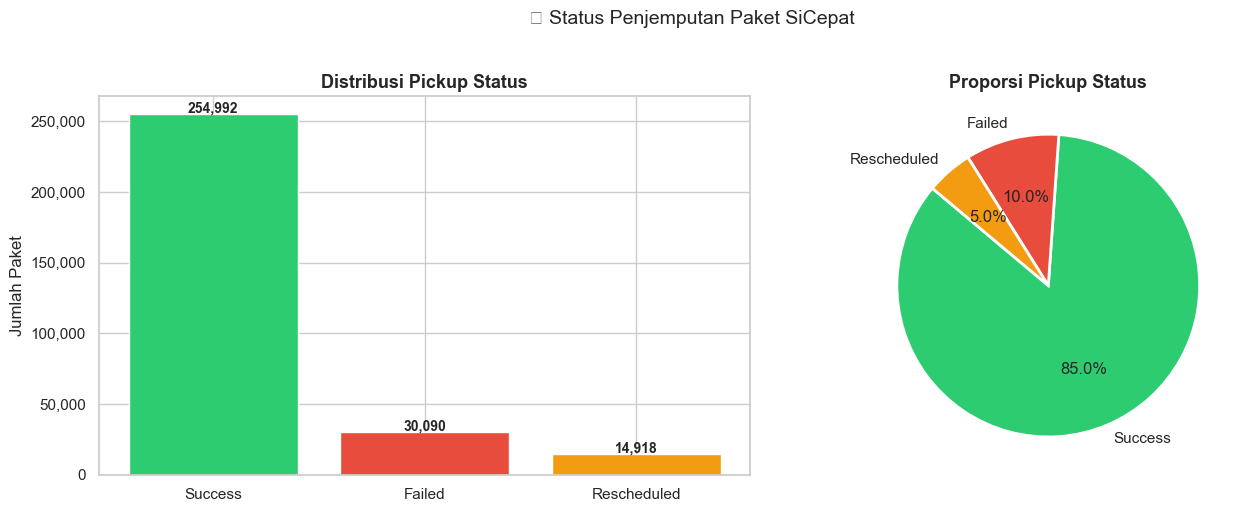

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = df['pickup_status'].value_counts()
colors = ['#2ECC71','#E74C3C','#F39C12']

# Bar Chart — axes[0]
axes[0].bar(sc.index, sc.values, color=colors, edgecolor='white')
for i,(k,v) in enumerate(sc.items()):
    axes[0].text(i, v+1000, f'{v:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribusi Pickup Status', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Paket')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Pie Chart — axes[1]
# autopct='%1.1f%%' → format persentase 1 desimal
axes[1].pie(sc.values, labels=sc.index, autopct='%1.1f%%',
            colors=colors, startangle=140,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Proporsi Pickup Status', fontsize=13, fontweight='bold')

plt.suptitle('📦 Status Penjemputan Paket SiCepat', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


## **6.2 Histogram — Distribusi Berat Paket**


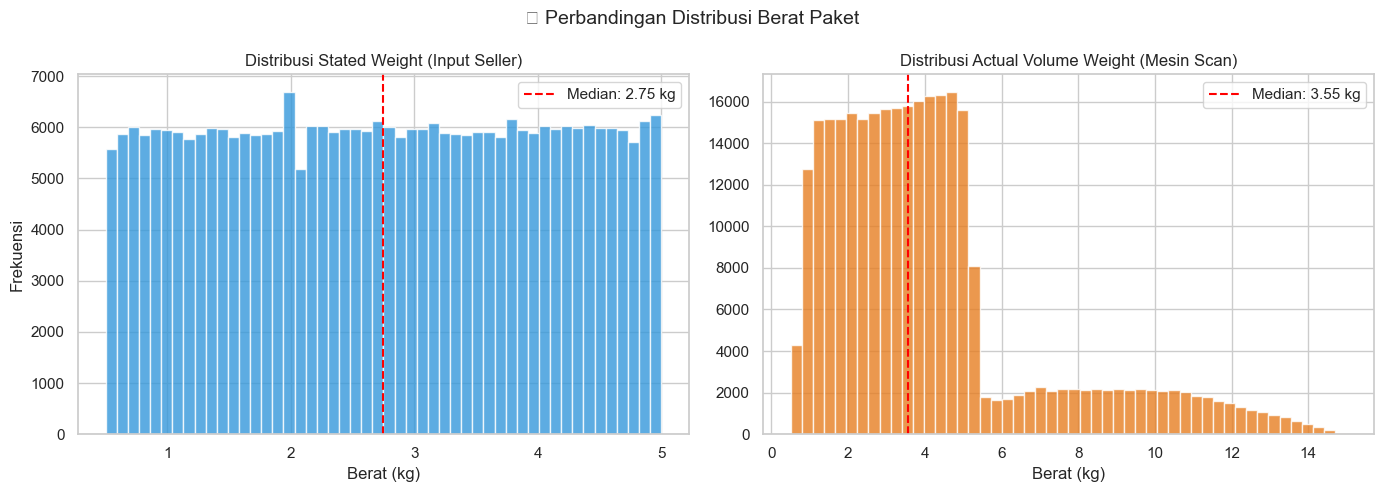

In [ ]:
df_plot = df_valid[df_valid['is_weight_valid']]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_plot['stated_weight_kg'], bins=50, color='#3498DB', alpha=0.8, edgecolor='white')
axes[0].axvline(df_plot['stated_weight_kg'].median(), color='red', linestyle='--',
                label=f'Median: {df_plot["stated_weight_kg"].median():.2f} kg')
axes[0].set_title('Distribusi Stated Weight (Input Seller)')
axes[0].set_xlabel('Berat (kg)'); axes[0].set_ylabel('Frekuensi'); axes[0].legend()

axes[1].hist(df_plot['actual_volume_weight_kg'], bins=50, color='#E67E22', alpha=0.8, edgecolor='white')
axes[1].axvline(df_plot['actual_volume_weight_kg'].median(), color='red', linestyle='--',
                label=f'Median: {df_plot["actual_volume_weight_kg"].median():.2f} kg')
axes[1].set_title('Distribusi Actual Volume Weight (Mesin Scan)')
axes[1].set_xlabel('Berat (kg)'); axes[1].legend()

plt.suptitle('📊 Perbandingan Distribusi Berat Paket', fontsize=14)
plt.tight_layout(); plt.show()


## **6.3 Boxplot — Berat per Layanan**

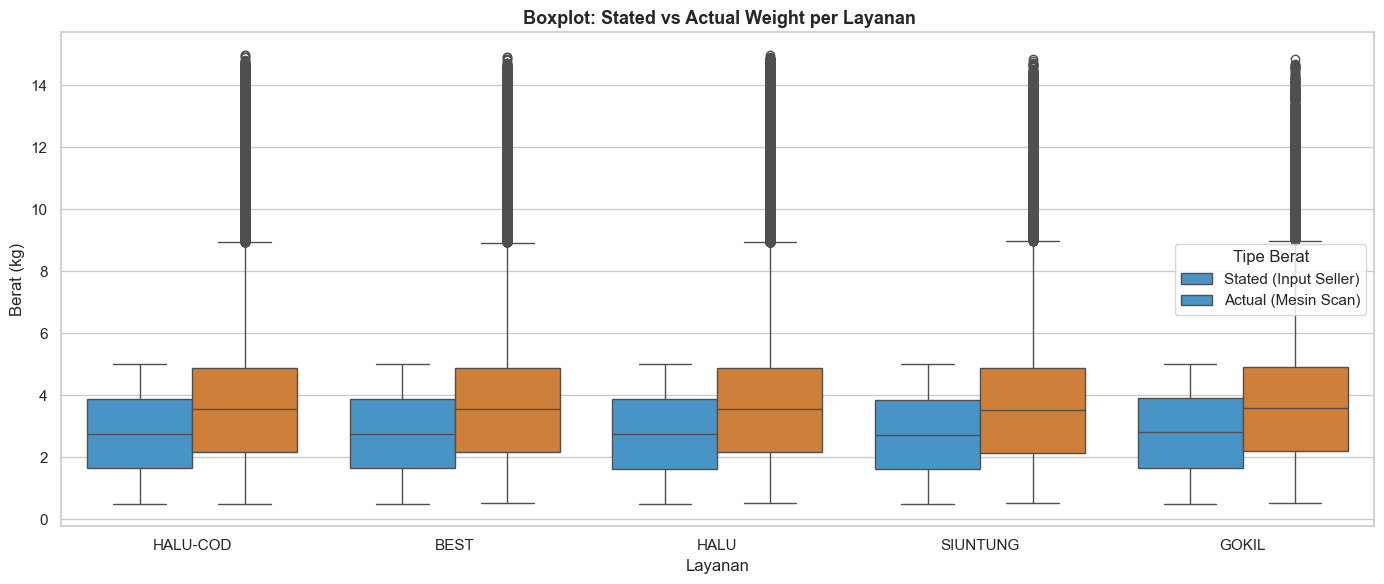

 Kotak biru (Stated) selalu lebih rendah dari oranye (Actual) → leakage di semua layanan


In [ ]:
df_melt = df_valid[df_valid['is_weight_valid']].melt(
    id_vars='service_name',
    value_vars=['stated_weight_kg','actual_volume_weight_kg'],
    var_name='weight_type', value_name='weight_kg'
)

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_melt[df_melt['weight_kg']<=15],
            x='service_name', y='weight_kg',
            hue='weight_type', palette=['#3498DB','#E67E22'])
plt.title(' Boxplot: Stated vs Actual Weight per Layanan', fontsize=13, fontweight='bold')
plt.xlabel('Layanan'); plt.ylabel('Berat (kg)')
plt.legend(title='Tipe Berat', labels=['Stated (Input Seller)','Actual (Mesin Scan)'])
plt.tight_layout(); plt.show()
print(' Kotak biru (Stated) selalu lebih rendah dari oranye (Actual) → leakage di semua layanan')


## **6.4 Bar Horizontal — Top 10 Seller Revenue Leakage**

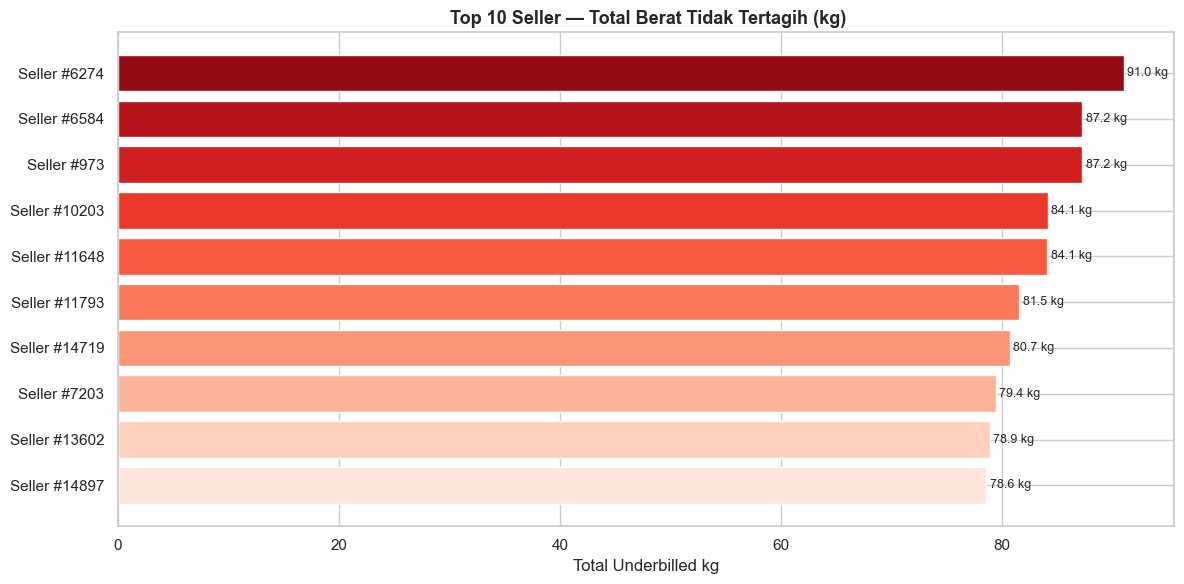

In [ ]:
plt.figure(figsize=(12, 6))
labels = top10['seller_name'].str.replace('Toko Seller Sukses ','Seller #')
bars = plt.barh(labels, top10['total_underbilled_kg'],
                color=sns.color_palette('Reds_r', 10), edgecolor='white')
for bar in bars:
    w = bar.get_width()
    plt.text(w+0.3, bar.get_y()+bar.get_height()/2, f'{w:.1f} kg', va='center', fontsize=9)
plt.title(' Top 10 Seller — Total Berat Tidak Tertagih (kg)', fontsize=13, fontweight='bold')
plt.xlabel('Total Underbilled kg')
plt.gca().invert_yaxis()  # Seller terbesar di atas
plt.tight_layout(); plt.show()

## **6.5 Line Plot — SLA Miss per Jam**

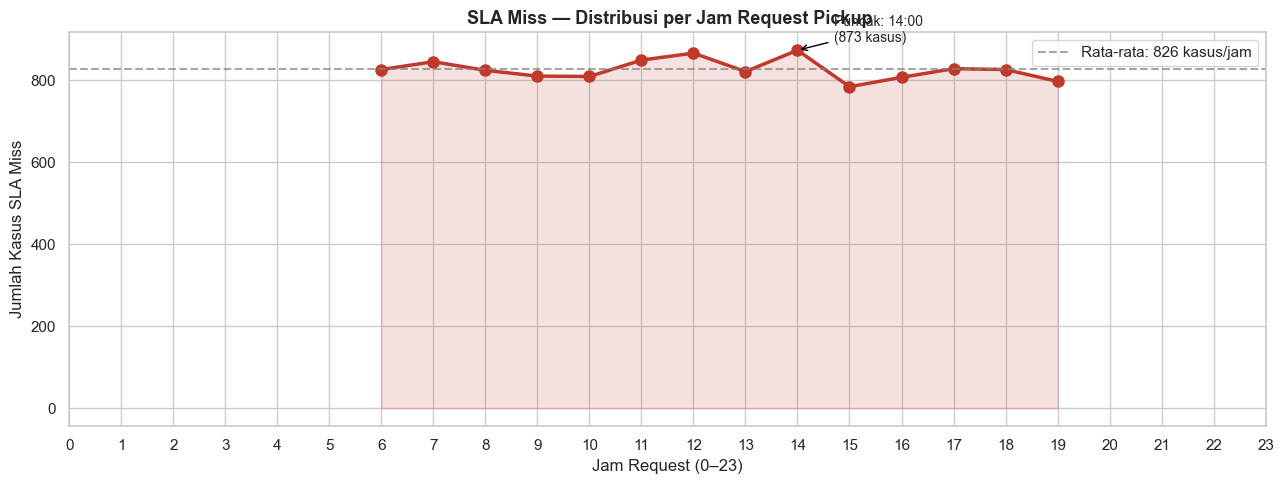

 SLA miss merata 06:00-19:00 → masalah kapasitas armada, bukan jam tertentu


In [ ]:
sla_by_hour = df_miss['request_hour'].value_counts().sort_index()

plt.figure(figsize=(13, 5))
plt.plot(sla_by_hour.index, sla_by_hour.values, marker='o', linewidth=2.5, color='#C0392B', markersize=8)
plt.fill_between(sla_by_hour.index, sla_by_hour.values, alpha=0.15, color='#C0392B')
plt.axhline(sla_by_hour.mean(), linestyle='--', color='gray', alpha=0.7,
            label=f'Rata-rata: {sla_by_hour.mean():.0f} kasus/jam')
peak = sla_by_hour.idxmax()
plt.annotate(f'Puncak: {peak}:00\n({sla_by_hour.max()} kasus)',
             xy=(peak, sla_by_hour.max()), xytext=(peak+0.7, sla_by_hour.max()+20),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=10)
plt.title(' SLA Miss — Distribusi per Jam Request Pickup', fontsize=13, fontweight='bold')
plt.xlabel('Jam Request (0–23)'); plt.ylabel('Jumlah Kasus SLA Miss')
plt.xticks(range(0,24)); plt.legend(); plt.tight_layout(); plt.show()
print(' SLA miss merata 06:00-19:00 → masalah kapasitas armada, bukan jam tertentu')

## **6.6 Heatmap — Korelasi Variabel Berat**


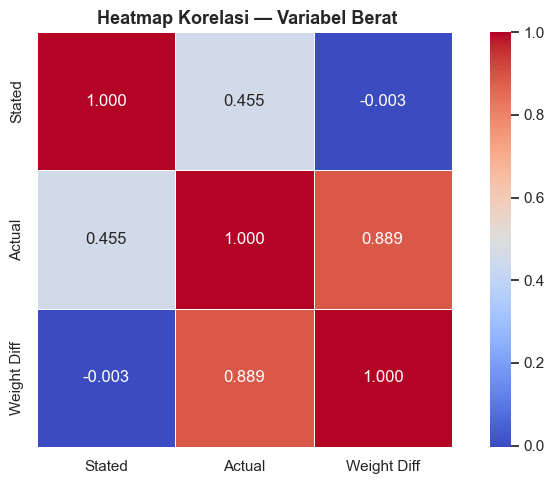

In [ ]:
df_c = df_valid[df_valid['is_weight_valid']][['stated_weight_kg','actual_volume_weight_kg']].copy()
df_c['weight_diff'] = df_c['actual_volume_weight_kg'] - df_c['stated_weight_kg']

plt.figure(figsize=(8, 5))
sns.heatmap(df_c.corr().round(3), annot=True, fmt='.3f',
            cmap='coolwarm', linewidths=0.5, square=True,
            xticklabels=['Stated','Actual','Weight Diff'],
            yticklabels=['Stated','Actual','Weight Diff'])
plt.title(' Heatmap Korelasi — Variabel Berat', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## **6.7 Scatter Plot — Stated vs Actual Weight**


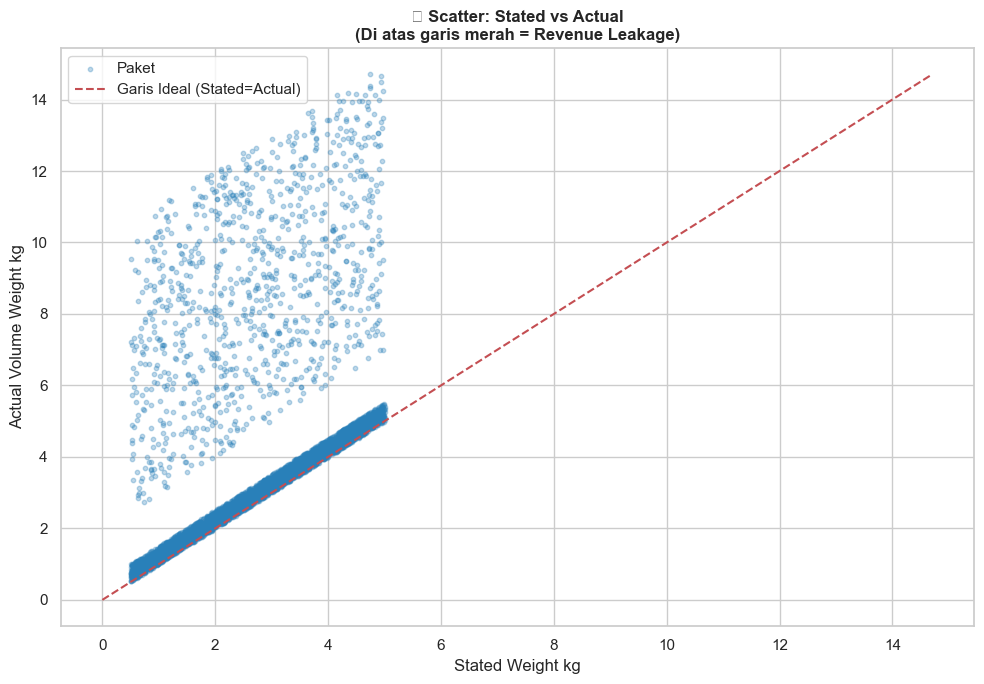

In [ ]:
sample = df_valid[df_valid['is_weight_valid']].sample(5000, random_state=42)

plt.figure(figsize=(10, 7))
plt.scatter(sample['stated_weight_kg'], sample['actual_volume_weight_kg'],
            alpha=0.3, s=10, color='#2980B9', label='Paket')
mv = max(sample['stated_weight_kg'].max(), sample['actual_volume_weight_kg'].max())
plt.plot([0,mv],[0,mv],'r--',linewidth=1.5, label='Garis Ideal (Stated=Actual)')
plt.title('🔵 Scatter: Stated vs Actual\n(Di atas garis merah = Revenue Leakage)', fontsize=12, fontweight='bold')
plt.xlabel('Stated Weight kg'); plt.ylabel('Actual Volume Weight kg')
plt.legend(); plt.tight_layout(); plt.show()


## **6.8 Bar Chart — % Anomali per Layanan**

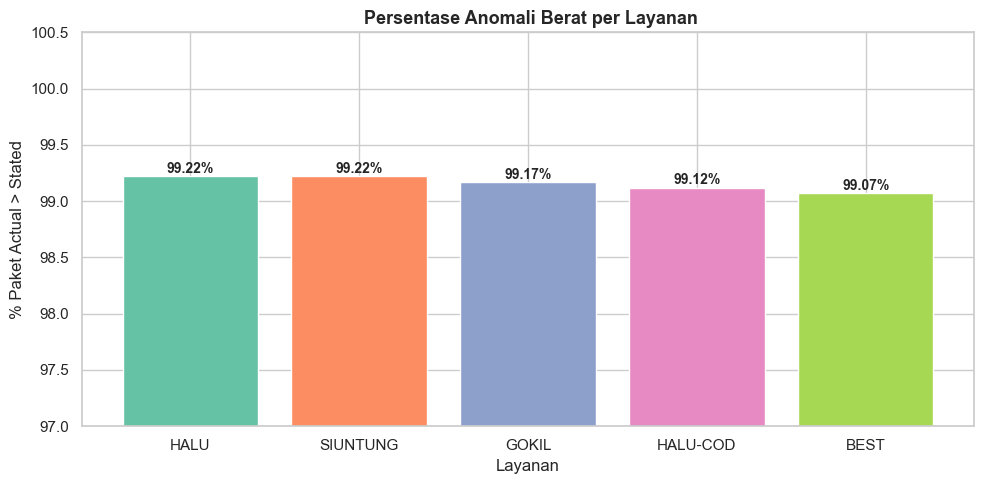

 Semua layanan ~99% anomali : manipulasi tidak terkait jenis layanan


In [ ]:
plt.figure(figsize=(10, 5))
bars = plt.bar(anomaly_svc.index, anomaly_svc['pct_anomali'],
               color=sns.color_palette('Set2', len(anomaly_svc)), edgecolor='white')
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, h+0.03,
             f'{h:.2f}%', ha='center', fontsize=10, fontweight='bold')
plt.ylim(97, 100.5)  # Zoom sumbu Y agar perbedaan terlihat
plt.title(' Persentase Anomali Berat per Layanan', fontsize=13, fontweight='bold')
plt.xlabel('Layanan'); plt.ylabel('% Paket Actual > Stated')
plt.tight_layout(); plt.show()
print(' Semua layanan ~99% anomali : manipulasi tidak terkait jenis layanan')


# **7. Hypothesis Testing**

Uji statistik untuk menjawab pertanyaan secara ilmiah dengan data.

## Langkah:
- Rumuskan **H₀** dan **H₁**
- Tentukan **α** (level signifikansi, biasanya 0.05)
- Hitung **p-value**
- **Keputusan**: p < α → Tolak H₀ | p ≥ α → Gagal Tolak H₀

## **7.1 Independent t-test — HALU vs BEST**

**H₀:** μ_HALU = μ_BEST | **H₁:** μ_HALU ≠ μ_BEST | **α = 0.05**


In [ ]:
# Ambil weight_diff per layanan
halu_diff = df_valid2[df_valid2['service_name']=='HALU']['weight_diff'].dropna()
best_diff = df_valid2[df_valid2['service_name']=='BEST']['weight_diff'].dropna()

t_stat, p_val = stats.ttest_ind(halu_diff, best_diff)

print('=' * 55)
print('   INDEPENDENT SAMPLE T-TEST: HALU vs BEST')
print('=' * 55)
print(f'  n HALU              : {len(halu_diff):,}')
print(f'  n BEST              : {len(best_diff):,}')
print(f'  Mean HALU diff (kg) : {halu_diff.mean():.4f}')
print(f'  Mean BEST diff (kg) : {best_diff.mean():.4f}')
print(f'  t-statistic         : {t_stat:.4f}')
print(f'  p-value             : {p_val:.6f}')
print('-' * 55)
if p_val < 0.05:
    print(f'   TOLAK H₀ (p={p_val:.4f} < 0.05)')
    print('  → Ada perbedaan signifikan — tapi perbedaannya sangat kecil')
else:
    print(f'   GAGAL TOLAK H₀ (p={p_val:.4f} ≥ 0.05)')
    print('  → Tidak ada perbedaan signifikan antara HALU dan BEST')
print('=' * 55)

   INDEPENDENT SAMPLE T-TEST: HALU vs BEST
  n HALU              : 148,590
  n BEST              : 44,655
  Mean HALU diff (kg) : 1.3977
  Mean BEST diff (kg) : 1.4036
  t-statistic         : -0.4302
  p-value             : 0.667033
-------------------------------------------------------
   GAGAL TOLAK H₀ (p=0.6670 ≥ 0.05)
  → Tidak ada perbedaan signifikan antara HALU dan BEST


## **7.2 Chi-Square Test — Layanan vs SLA Status**
**H₀:** Tidak ada asosiasi antara jenis layanan dan SLA status | **α = 0.05**

In [ ]:

df_chi = df_sla.copy()
contingency = pd.crosstab(df_chi['service_name'], df_chi['sla_status'])

print('=== CROSS TABULATION: Service vs SLA Status ===')
display(contingency)

# Output: (chi2, p_value, degrees_of_freedom, expected_frequencies)
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)

print(f'\nChi² Statistic  : {chi2:.4f}')
print(f'p-value         : {p_chi:.6f}')
print(f'Degrees of Freedom: {dof}')

if p_chi < 0.05:
    print('\nTOLAK H₀: Ada asosiasi signifikan antara layanan dan SLA status')
else:
    print('\nGAGAL TOLAK H₀: Tidak ada asosiasi signifikan')

=== CROSS TABULATION: Service vs SLA Status ===


sla_status,SLA Hit (≤24 jam),SLA Miss (>24 jam)
service_name,,
BEST,38053,1740
GOKIL,12648,575
HALU,126606,5795
HALU-COD,50642,2331
SIUNTUNG,25201,1124



Chi² Statistic  : 0.7800
p-value         : 0.941110
Degrees of Freedom: 4

GAGAL TOLAK H₀: Tidak ada asosiasi signifikan


# **8. Kesimpulan & Rekomendasi**

## **8.1 Kesimpulan**

| # | Pertanyaan | Jawaban | Urgensi |
|---|---|---|---|
| Q1 | Revenue Leakage | **~416.161 kg / Rp 2,91 M** tidak tertagih | 🔴 Kritis |
| Q2 | Top Seller | 10 seller masing-masing manipulasi >78 kg | 🔴 Kritis |
| Q3 | SLA Miss | **11.687 kasus (4.37%)**, merata 06:00–19:00 | 🟡 Sedang |
| Q4 | Item Category | 11 nilai kotor → **4 kategori bersih** | 🟡 Sedang |
| Q5 | Phantom Pickup | **10.199 kasus (3.40%)** manipulasi timestamp | 🔴 Kritis |
| Q6 | HALU vs BEST | Tidak ada perbedaan signifikan (~99% keduanya) | 🟢 Informatif |

## **8.2 Rekomendasi**

- **Auto-Chargeback System** — tagih otomatis ke marketplace berdasarkan selisih berat scan vs stated
- **Phantom Pickup Alert** — validasi backend: pickup_time tidak boleh <`request_time
- **Server-side Timestamp** — ganti client-side timestamp agar tidak bisa dimanipulasi
- **Dropdown Item Category** — ganti input bebas dengan dropdown terstruktur di aplikasi seller
- **Evaluasi Kapasitas Armada** — tambah SiGESIT atau optimasi routing per zona